In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/credit_risk_dataset.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (32581, 12)

Columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

First 5 rows:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
print("Data types:\n", df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nMissing %:")
print((df.isnull().sum() / len(df) * 100).round(2))

Data types:
 person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Missing values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Missing %:
person_age                    0.00
person_income       

Target distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Default rate: 0.218


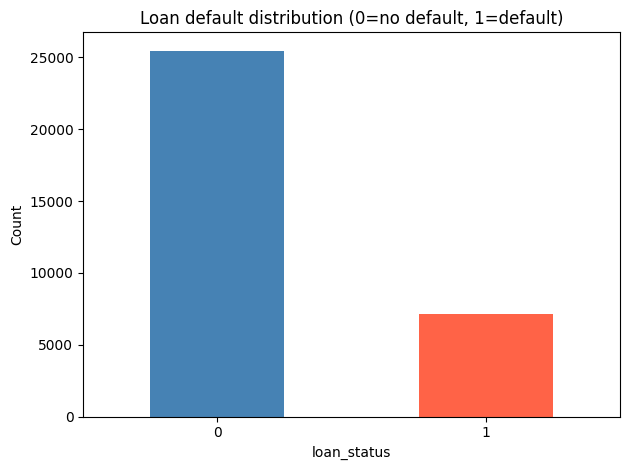

In [3]:
print("Target distribution:")
print(df['loan_status'].value_counts())
print("\nDefault rate:", df['loan_status'].mean().round(3))

df['loan_status'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Loan default distribution (0=no default, 1=default)')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

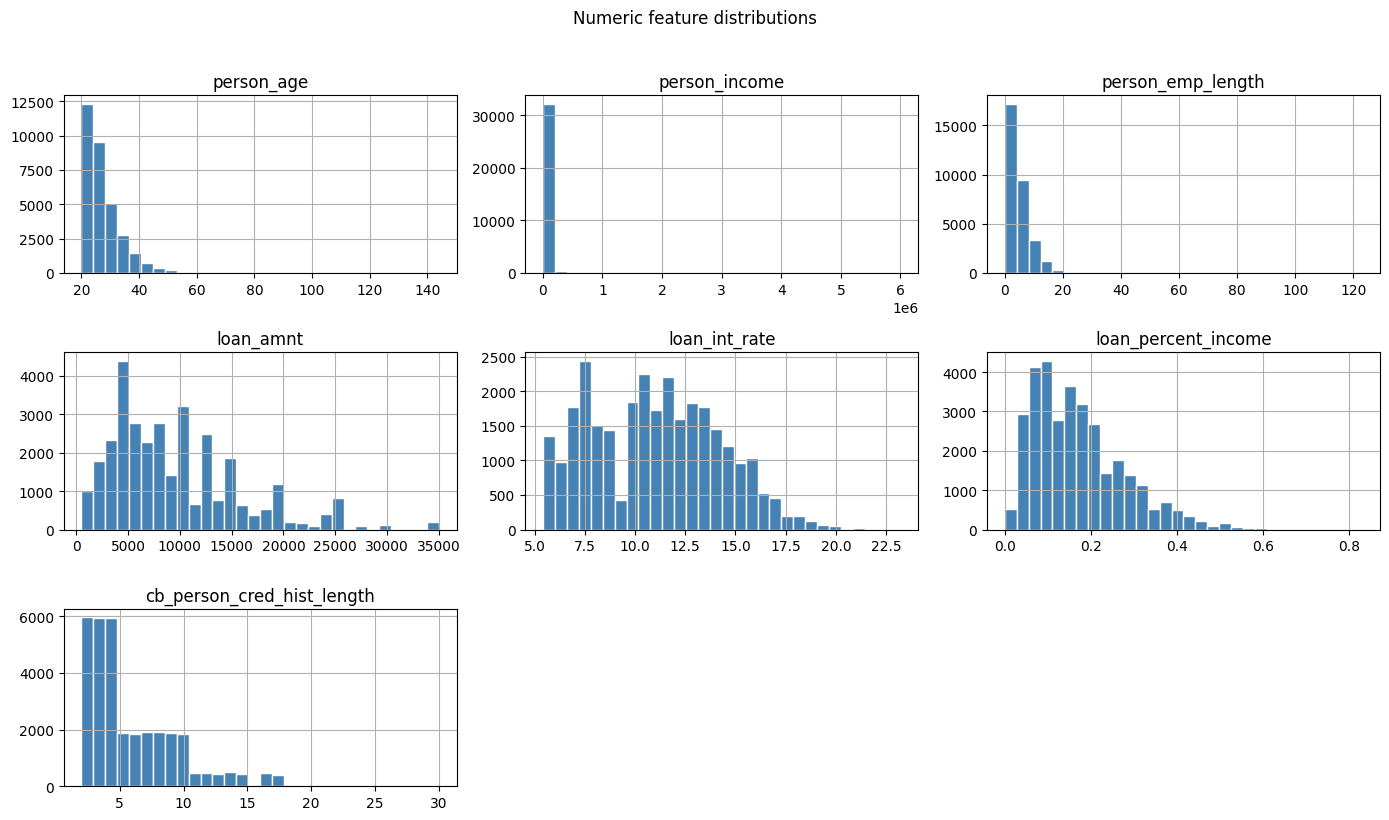

In [4]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length',
                'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                'cb_person_cred_hist_length']

df[numeric_cols].hist(bins=30, figsize=(14, 8), color='steelblue', edgecolor='white')
plt.suptitle('Numeric feature distributions', y=1.02)
plt.tight_layout()
plt.show()

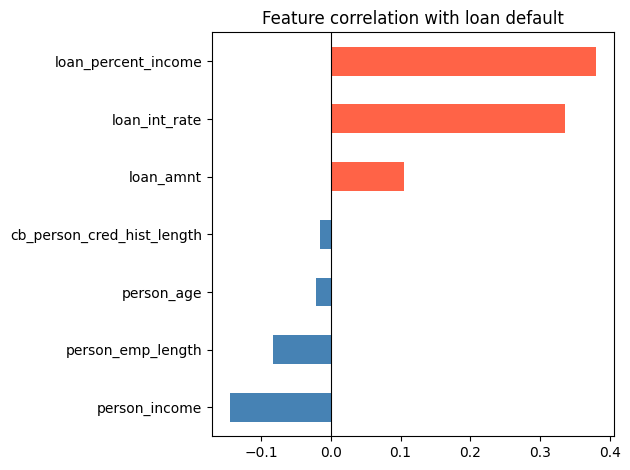

In [5]:
corr = df[numeric_cols + ['loan_status']].corr()['loan_status'].drop('loan_status').sort_values()

corr.plot(kind='barh', color=['tomato' if v > 0 else 'steelblue' for v in corr])
plt.title('Feature correlation with loan default')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

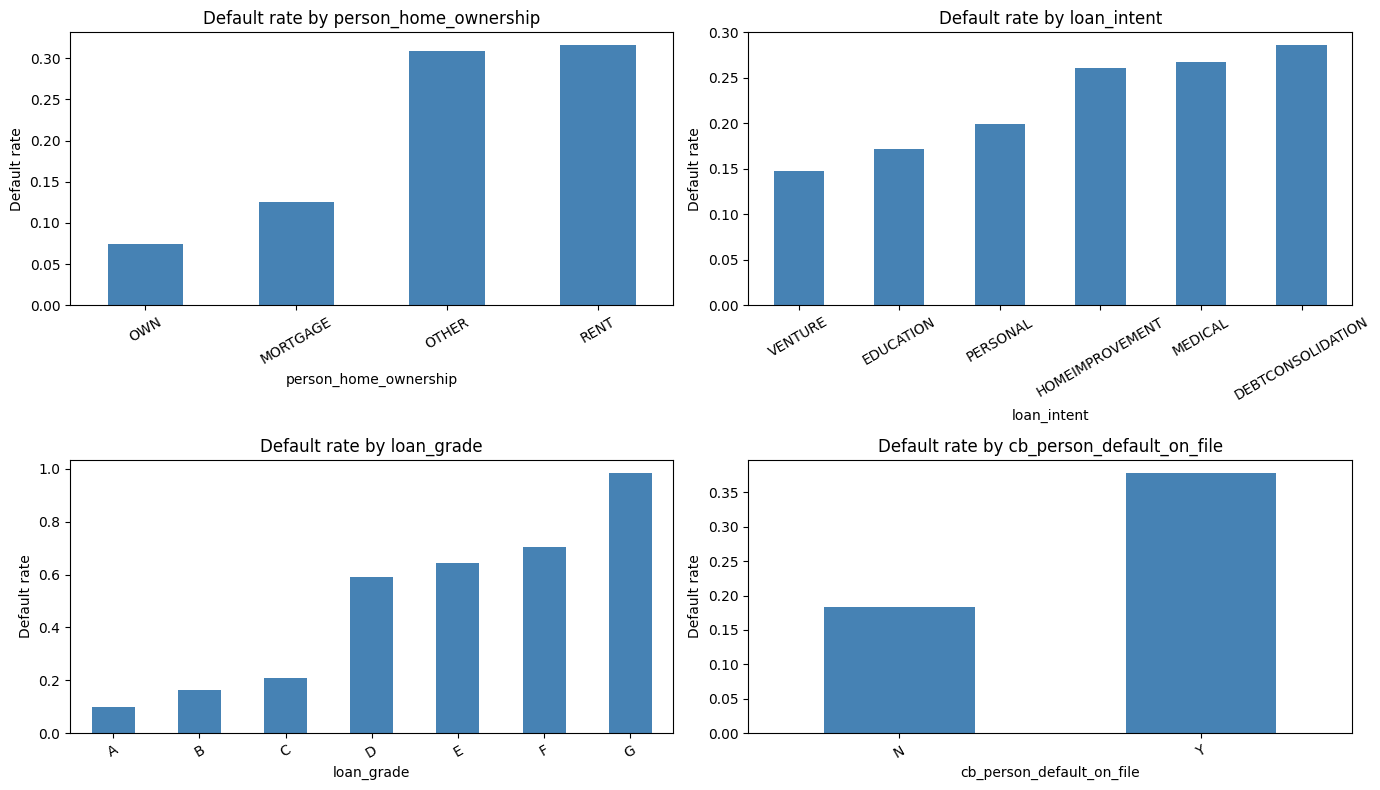

In [6]:
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    df.groupby(col)['loan_status'].mean().sort_values().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Default rate by {col}')
    ax.set_ylabel('Default rate')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [7]:
print("""
EDA Summary — credit risk dataset
==================================
Rows: 32,581  |  Columns: 12  |  Target: loan_status

Missing values:
  - loan_int_rate: ~9.6% missing
  - person_emp_length: ~2.7% missing

Class imbalance:
  - No default (0): ~78%
  - Default (1):    ~22%  ← important for model choice

Strong predictors (from correlation):
  - loan_percent_income: high positive correlation with default
  - loan_grade: higher grade = lower default rate
  - loan_int_rate: higher rate = more defaults

Outliers spotted:
  - person_age has values >100 → needs cleaning in W3
  - person_income has extreme values → needs capping

Next step: W3 — feature engineering and preprocessing pipeline
""")


EDA Summary — credit risk dataset
Rows: 32,581  |  Columns: 12  |  Target: loan_status

Missing values:
  - loan_int_rate: ~9.6% missing
  - person_emp_length: ~2.7% missing

Class imbalance:
  - No default (0): ~78%
  - Default (1):    ~22%  ← important for model choice

Strong predictors (from correlation):
  - loan_percent_income: high positive correlation with default
  - loan_grade: higher grade = lower default rate
  - loan_int_rate: higher rate = more defaults

Outliers spotted:
  - person_age has values >100 → needs cleaning in W3
  - person_income has extreme values → needs capping

Next step: W3 — feature engineering and preprocessing pipeline

